Generating physics-compliant dataset...

1. DISPLAYING INPUTS (FEATURES) AND OUTPUTS (TARGETS)

--- First 5 Rows of INPUTS (What ESP32 sends) ---
      Voltage   Current      Power  Relay_1  Relay_2  Battery_Level  \
0  232.779131  0.052889  12.311377      0.0      0.0     100.000000   
1  225.861130 -0.053610 -12.108430      0.0      0.0     100.000121   
2  227.698690  0.007631   1.737608      0.0      0.0     100.000104   
3  229.026396  0.058895  13.488411      0.0      0.0      99.999969   
4  232.555856  0.140465  32.665944      0.0      0.0      99.999642   

   Hour_of_Day  
0            0  
1            0  
2            0  
3            0  
4            0  

--- First 5 Rows of OUTPUTS (What AI predicts) ---
   Load_Type  Is_Anomaly  Predicted_Power_Next
0          0           0            -12.108430
1          0           0              1.737608
2          0           0             13.488411
3          0           0             32.665944
4          0           0             3

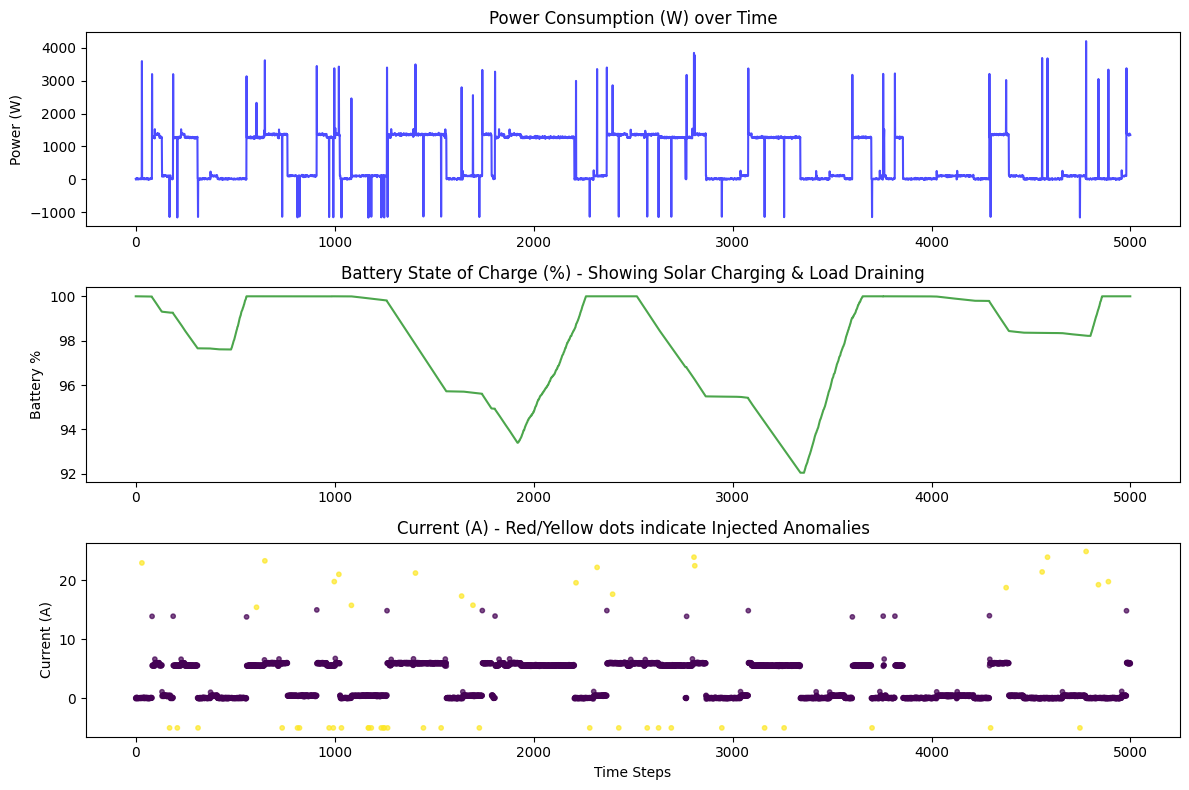

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. PHYSICAL CONSTANTS & SYSTEM PARAMETERS
# ==========================================
NUM_SAMPLES = 5000  # Number of data points (e.g., 5000 seconds/minutes)
BASE_VOLTAGE = 230.0  # Nominal voltage (regulated by buck booster/inverter)
VOLTAGE_NOISE = 2.0   # Minor sensor/voltage fluctuation

# Load Profiles (Thermodynamic/Electrical signatures)
LIGHT_LOAD_CURRENT = 0.4   # Amps (e.g., LED lights, small fan)
HEAVY_LOAD_CURRENT = 5.5   # Amps (e.g., heater, large motor)
INRUSH_MULTIPLIER = 2.5    # Startup current spike multiplier

# ==========================================
# 2. DATA GENERATION FUNCTIONS
# ==========================================
def generate_physics_compliant_data(n_samples):
    # Initialize arrays
    time = np.arange(n_samples)
    hour_of_day = (time // 60) % 24 # Simulating minutes, converting to hours

    relay1 = np.zeros(n_samples)
    relay2 = np.zeros(n_samples)
    current = np.zeros(n_samples)
    voltage = np.zeros(n_samples)
    battery_level = np.zeros(n_samples)
    is_anomaly = np.zeros(n_samples, dtype=int)

    # Simulate Relay States (Random switching with some persistence)
    # Relay 1 (Light Load) turns on/off
    r1_state = 0
    for i in range(n_samples):
        if np.random.rand() < 0.01: # 1% chance to toggle
            r1_state = 1 - r1_state
        relay1[i] = r1_state

    # Relay 2 (Heavy Load) turns on/off less frequently
    r2_state = 0
    for i in range(n_samples):
        if np.random.rand() < 0.005: # 0.5% chance to toggle
            r2_state = 1 - r2_state
        relay2[i] = r2_state

    # Simulate Current based on Relay States & Thermodynamics
    for i in range(n_samples):
        base_current = 0.05 # Idle leakage current

        if relay1[i] == 1:
            base_current += LIGHT_LOAD_CURRENT
            # Simulate thermodynamic inrush current at the exact moment of turning ON
            if i > 0 and relay1[i-1] == 0:
                base_current *= INRUSH_MULTIPLIER

        if relay2[i] == 1:
            base_current += HEAVY_LOAD_CURRENT
            if i > 0 and relay2[i-1] == 0:
                base_current *= INRUSH_MULTIPLIER

        # Add sensor noise to current
        current[i] = base_current + np.random.normal(0, 0.05)

        # Simulate Voltage (Buck booster keeps it stable, but heavy loads cause slight sag)
        v_sag = 0.5 * relay2[i] # Voltage drops slightly under heavy load
        voltage[i] = BASE_VOLTAGE - v_sag + np.random.normal(0, VOLTAGE_NOISE)

        # Simulate Battery Drain (Thermodynamic energy consumption)
        if i == 0:
            battery_level[i] = 100.0
        else:
            # Drain battery based on power drawn
            power_drawn = voltage[i] * current[i]
            drain_rate = (power_drawn / 1000) * 0.01 # Simplified drain math
            battery_level[i] = max(0, battery_level[i-1] - drain_rate)

            # Simulate Solar Charging during "Daytime" (Hours 8 to 17)
            if 8 <= hour_of_day[i] <= 17:
                solar_charge = np.random.uniform(0.01, 0.05)
                battery_level[i] = min(100, battery_level[i] + solar_charge)

    # ==========================================
    # 3. INJECTING ANOMALIES (FAULT CONDITIONS)
    # ==========================================
    # Fault 1: Short Circuit / Severe Overload (Random 20 instances)
    fault_indices = np.random.choice(n_samples, 20, replace=False)
    for idx in fault_indices:
        current[idx] = np.random.uniform(15.0, 25.0) # Massive current spike
        voltage[idx] = np.random.uniform(150.0, 180.0) # Severe voltage drop
        is_anomaly[idx] = 1

    # Fault 2: Sensor Glitch / Noise (Random 30 instances)
    glitch_indices = np.random.choice(n_samples, 30, replace=False)
    for idx in glitch_indices:
        current[idx] = -5.0 # Negative current (physically impossible for this DC/AC setup)
        is_anomaly[idx] = 1

    # ==========================================
    # 4. CALCULATING POWER & TARGETS
    # ==========================================
    # Enforce P = V * I (Joule's Law)
    power = voltage * current

    # Define Target: Load Type (0: Idle, 1: Light, 2: Heavy, 3: Both)
    load_type = np.zeros(n_samples, dtype=int)
    load_type[(relay1 == 1) & (relay2 == 0)] = 1
    load_type[(relay1 == 0) & (relay2 == 1)] = 2
    load_type[(relay1 == 1) & (relay2 == 1)] = 3

    # Define Target: Predicted Power for next step (Shifted array for Time-Series)
    predicted_power_next = np.roll(power, -1)
    predicted_power_next[-1] = power[-1] # Handle the last element

    # ==========================================
    # 5. BUILDING THE PANDAS DATAFRAME
    # ==========================================
    df = pd.DataFrame({
        # --- INPUTS (Features for ML) ---
        'Voltage': voltage,
        'Current': current,
        'Power': power,
        'Relay_1': relay1,
        'Relay_2': relay2,
        'Battery_Level': battery_level,
        'Hour_of_Day': hour_of_day,

        # --- OUTPUTS (Targets for ML) ---
        'Load_Type': load_type,             # Classification Target
        'Is_Anomaly': is_anomaly,           # Anomaly Detection Target
        'Predicted_Power_Next': predicted_power_next # Regression Target
    })

    return df

# ==========================================
# RUN AND DISPLAY
# ==========================================
if __name__ == "__main__":
    print("Generating physics-compliant dataset...")
    df = generate_physics_compliant_data(NUM_SAMPLES)

    # 1. Display Inputs and Outputs
    print("\n" + "="*50)
    print("1. DISPLAYING INPUTS (FEATURES) AND OUTPUTS (TARGETS)")
    print("="*50)

    inputs = ['Voltage', 'Current', 'Power', 'Relay_1', 'Relay_2', 'Battery_Level', 'Hour_of_Day']
    outputs = ['Load_Type', 'Is_Anomaly', 'Predicted_Power_Next']

    print("\n--- First 5 Rows of INPUTS (What ESP32 sends) ---")
    print(df[inputs].head())

    print("\n--- First 5 Rows of OUTPUTS (What AI predicts) ---")
    print(df[outputs].head())

    # 2. Check Thermodynamic/Physical Conditions
    print("\n" + "="*50)
    print("2. PHYSICAL & THERMODYNAMIC CONDITION CHECKS")
    print("="*50)

    # Check 1: Power Equation (P = V * I)
    calculated_power = df['Voltage'] * df['Current']
    power_error = np.abs(calculated_power - df['Power']).mean()
    print(f"\n[Check 1] Joule's Law (P = V x I): Mean calculation error = {power_error:.6f} W (Should be ~0)")

    # Check 2: Current limits
    print(f"[Check 2] Current Limits: Min = {df['Current'].min():.2f}A, Max = {df['Current'].max():.2f}A")
    print("         (Note: Negative values exist only in injected sensor glitch anomalies)")

    # Check 3: Battery constraints
    print(f"[Check 3] Battery SoC Limits: Min = {df['Battery_Level'].min():.1f}%, Max = {df['Battery_Level'].max():.1f}%")
    print("         (Battery never exceeds 100% or drops below 0%)")

    # Check 4: Anomaly distribution
    anomaly_count = df['Is_Anomaly'].sum()
    print(f"[Check 4] Anomaly Injection: {anomaly_count} anomalous data points out of {NUM_SAMPLES} ({(anomaly_count/NUM_SAMPLES)*100:.2f}%)")

    # Save to CSV for your ML pipeline
    csv_filename = "esp32_solar_energy_dataset.csv"
    df.to_csv(csv_filename, index=False)
    print(f"\n✅ Dataset successfully generated and saved as '{csv_filename}'!")

    # Optional: Plot the data to visualize the physical behavior
    plt.figure(figsize=(12, 8))

    plt.subplot(3, 1, 1)
    plt.plot(df['Power'], color='blue', alpha=0.7)
    plt.title('Power Consumption (W) over Time')
    plt.ylabel('Power (W)')

    plt.subplot(3, 1, 2)
    plt.plot(df['Battery_Level'], color='green', alpha=0.7)
    plt.title('Battery State of Charge (%) - Showing Solar Charging & Load Draining')
    plt.ylabel('Battery %')

    plt.subplot(3, 1, 3)
    plt.scatter(df.index, df['Current'], c=df['Is_Anomaly'], cmap='viridis', s=10, alpha=0.7)
    plt.title('Current (A) - Red/Yellow dots indicate Injected Anomalies')
    plt.ylabel('Current (A)')
    plt.xlabel('Time Steps')

    plt.tight_layout()
    plt.show()